# pruning-mnist-ffnn-pytorch

Magnitude-based weight pruning via `nnx.prune.magnitude_prune`: sparsity sweep on an MNIST FFN, plotting the validation-accuracy-vs-sparsity Pareto curve. 2:4 semi-structured pruning is mentioned but skipped on CPU (it requires CUDA + Ampere+).


# 1. Overview

## 1.1 Task & motivation

Weight pruning makes a trained model sparse — most of the weights become exactly 0 — so the deployed model is smaller (compressible to non-zero entries only) and, on hardware that supports sparse kernels, faster. The simplest recipe is **magnitude pruning**: zero the smallest-|w| fraction in each layer.

The interesting question is *how aggressive can you go* before accuracy collapses. This notebook sweeps sparsity from 10 % to 90 % on a single trained baseline and plots the trade-off.

## 1.2 Dataset summary

MNIST handwritten digits via `nnx.NNDataset`.

## 1.3 Approach in one paragraph

Train one FP32 baseline. For each target sparsity s in `[0.1, 0.3, 0.5, 0.7, 0.9]`, deep-copy the baseline, apply `nnx.prune.magnitude_prune(net, sparsity=s)`, measure validation accuracy + actual zero-fraction. Plot accuracy and zero-fraction vs target s.

## 1.4 Libraries used

`nnx` (`NNModel`, `NNDataset`, `nnx.prune.magnitude_prune`), `torch`, `torchvision`, `matplotlib`, `prettytable`.


# 2. Environment & Setup

## 2.1 Imports

In [1]:
SMOKE_TEST = 0
SMOKE_TEST_EPOCHS = 1


In [2]:
import copy

import torch
import torchvision as thv
import matplotlib.pyplot as plt
from prettytable import PrettyTable

import nnx
import nnx.prune as nnx_prune
from nnx.nn.dataset.nn_dataset import NNDataset
from nnx.nn.enum.activations import Activations
from nnx.nn.enum.devices import Devices
from nnx.nn.enum.losses import Losses
from nnx.nn.enum.nets import Nets
from nnx.nn.enum.optims import Optims
from nnx.nn.nn_model import NNModel
from nnx.nn.params.nn_model_params import NNModelParams
from nnx.nn.params.nn_optim_params import NNOptimParams
from nnx.nn.params.nn_params import NNParams
from nnx.nn.params.nn_train_params import NNTrainParams


## 2.2 Configuration / hyperparameters

In [3]:
DS_MEAN: float = 0.1307
DS_STD: float = 0.3081

HIDDEN_DIMS = [256, 128]
N_EPOCHS = SMOKE_TEST_EPOCHS if SMOKE_TEST else 3
LR = 1e-3
SPARSITY_LEVELS = [0.1] if SMOKE_TEST else [0.1, 0.3, 0.5, 0.7, 0.9]


## 2.3 Reproducibility (seed, device)

In [4]:
nnx.set_seed(0)
DEVICE = Devices.CPU


# 3. Data

## 3.1 Loading

In [5]:
ds = NNDataset(
    ds_class=thv.datasets.MNIST,
    transform=thv.transforms.Compose([
        thv.transforms.ToTensor(),
        thv.transforms.Normalize(mean=DS_MEAN, std=DS_STD),
    ]),
)
print(f"input_dim={ds.input_dim}, output_dim={ds.output_dim}")


input_dim=784, output_dim=10


## 3.2 Inspection / EDA

Same MNIST as the sibling pytorch-MNIST task — see that notebook's §3.

## 3.3 Preprocessing & splits

`NNDataset` provides the standard torchvision train/val split.


# 4. Model

## 4.1 Architecture


In [6]:
def make_model():
    return NNModel(
        net_params=NNParams(
            input_dim=ds.input_dim,
            output_dim=ds.output_dim,
            hidden_dims=HIDDEN_DIMS,
            dropout_prob=0.0,
            activation=Activations.RELU,
        ),
        params=NNModelParams(
            net=Nets.FEED_FWD,
            device=DEVICE,
            loss=Losses.CROSS_ENTROPY,
        ),
    )


## 4.2 Pruning contract

`nnx.prune.magnitude_prune(net, sparsity=s, layer_pattern="*", bake=True)`:

- L1-unstructured (smallest |w| zeroed) per matched layer.
- `bake=True` (default) writes the zeros into the actual `.weight` tensor and *removes* PyTorch's `weight_orig` + `weight_mask` reparam, so the post-prune `state_dict()` has the same keys as the unpruned net. This is the deployable form.
- Returns the number of layers that were pruned.

## 4.3 Why this design

Magnitude pruning is the simplest unstructured recipe and the right place to start for the Pareto-curve story. Structured 2:4 sparsity (`nnx.prune.semi_structured_24`) is a hardware-accelerated path — the underlying torchao kernel requires CUDA + Ampere+ — so it's mentioned in §6 but not run here.


# 5. Training

## 5.1 Train the FP32 baseline

In [7]:
model = make_model()
run = model.train(
    params=NNTrainParams(
        n_epochs=N_EPOCHS,
        train_loader=ds.train_loader,
        val_loader=ds.val_loader,
        optim=NNOptimParams(
            name=Optims.ADAM,
            max_lr=LR,
            momentum=(0.9, 0.999),
            weight_decay=0.0,
        ),
    ),
)
print(f"baseline: {len(run.idps)} iterations, final val_loss={run.idps[-1].val_edp.loss:.4f}")


+--------------------------------------------------------------+
|                        Run Details...                        |
+---------------------------+----------------------------------+
|             id            | d7606ebe41d3b8e848a487e86cdd3b85 |
|         model.net         |             feed_fwd             |
|         model.loss        |          cross_entropy           |
|        model.device       |               cpu                |
|       net.input_dim       |               784                |
|       net.output_dim      |                10                |
|      net.dropout_prob     |               0.0                |
|      net.hidden_dims      |            [256, 128]            |
|       net.activation      |               relu               |
|       train.n_epochs      |                3                 |
|     train.optim.max_lr    |              0.001               |
|    train.optim.momentum   |           (0.9, 0.999)           |
|      train.optim.name  

Training:   0%|          | 0/3 [00:00<?, ?it/s]

Training:  33%|███▎      | 1/3 [00:01<00:03,  1.97s/it]

Training:  33%|███▎      | 1/3 [00:02<00:03,  1.97s/it, error=0.6668, lr=0.0010]

Training:  67%|██████▋   | 2/3 [00:04<00:02,  2.14s/it, error=0.6668, lr=0.0010]

Training:  67%|██████▋   | 2/3 [00:04<00:02,  2.14s/it, error=0.5497, lr=0.0010]

Training: 100%|██████████| 3/3 [00:06<00:00,  2.15s/it, error=0.5497, lr=0.0010]

Training: 100%|██████████| 3/3 [00:06<00:00,  2.15s/it, error=0.4813, lr=0.0010]

Training: 100%|██████████| 3/3 [00:06<00:00,  2.20s/it, error=0.4813, lr=0.0010]


Run saved to /Users/kaveh/repos/ml-lab/.claude/worktrees/overnight-cleanup/runs/d7606ebe41d3b8e848a487e86cdd3b85
baseline: 3 iterations, final val_loss=1.8857


## 5.2 Sparsity sweep

For each `s`, deep-copy the baseline, prune to target sparsity, measure validation accuracy. The original `model` is left untouched so the next iteration starts from the same FP32 weights.


In [8]:
def eval_loss_acc(m, loader):
    m.net.eval()
    loss_fn = torch.nn.CrossEntropyLoss()
    correct, total, loss_sum, n_batches = 0, 0, 0.0, 0
    with torch.no_grad():
        for X, y in loader:
            X = X.view(X.size(0), -1).float()
            y = y.long()
            logits = m.net(X)
            loss_sum += loss_fn(logits, y).item()
            n_batches += 1
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return loss_sum / max(1, n_batches), correct / max(1, total)

def actual_zero_fraction(net):
    total, zeros = 0, 0
    for p in net.parameters():
        if p.ndim < 2:
            continue
        total += p.numel()
        zeros += (p == 0).sum().item()
    return zeros / total if total else 0.0

baseline_loss, baseline_acc = eval_loss_acc(model, ds.val_loader)
print(f"baseline (s=0.0): val_acc={baseline_acc*100:.2f}%, zero_frac={actual_zero_fraction(model.net):.4f}")

results = [("0.0 (baseline)", 0.0, baseline_acc, actual_zero_fraction(model.net))]
for s in SPARSITY_LEVELS:
    pruned = copy.deepcopy(model)
    n_pruned = nnx_prune.magnitude_prune(pruned.net, sparsity=s)
    _, acc = eval_loss_acc(pruned, ds.val_loader)
    zf = actual_zero_fraction(pruned.net)
    results.append((f"{s:.1f}", s, acc, zf))
    print(f"s={s:.1f}: pruned {n_pruned} layers, val_acc={acc*100:.2f}%, zero_frac={zf:.4f}")


baseline (s=0.0): val_acc=51.87%, zero_frac=0.0000
s=0.1: pruned 3 layers, val_acc=52.27%, zero_frac=0.1000


s=0.3: pruned 3 layers, val_acc=54.72%, zero_frac=0.3000
s=0.5: pruned 3 layers, val_acc=50.72%, zero_frac=0.5000


s=0.7: pruned 3 layers, val_acc=46.15%, zero_frac=0.7000


s=0.9: pruned 3 layers, val_acc=22.88%, zero_frac=0.9000


# 6. Evaluation & Results

## 6.1 Sparsity vs accuracy table

In [9]:
t = PrettyTable()
t.title = "Magnitude pruning on MNIST FFN ([256, 128])"
t.field_names = ["target sparsity", "val accuracy", "actual zero fraction (Linear weights)"]
for label, _, acc, zf in results:
    t.add_row([label, f"{acc*100:.2f}%", f"{zf*100:.2f}%"])
print(t)


+------------------------------------------------------------------------+
|              Magnitude pruning on MNIST FFN ([256, 128])               |
+-----------------+--------------+---------------------------------------+
| target sparsity | val accuracy | actual zero fraction (Linear weights) |
+-----------------+--------------+---------------------------------------+
|  0.0 (baseline) |    51.87%    |                 0.00%                 |
|       0.1       |    52.27%    |                 10.00%                |
|       0.3       |    54.72%    |                 30.00%                |
|       0.5       |    50.72%    |                 50.00%                |
|       0.7       |    46.15%    |                 70.00%                |
|       0.9       |    22.88%    |                 90.00%                |
+-----------------+--------------+---------------------------------------+


## 6.2 Pareto curve

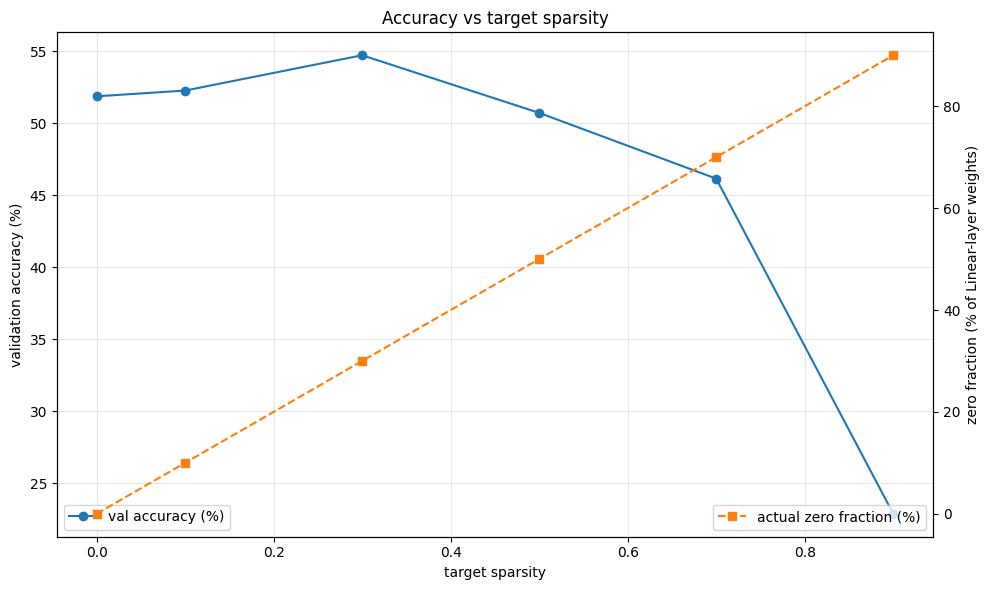

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))
xs = [s for _, s, _, _ in results]
accs = [acc for _, _, acc, _ in results]
zfs = [zf for _, _, _, zf in results]

ax.plot(xs, [a*100 for a in accs], "o-", label="val accuracy (%)", color="tab:blue")
ax.set_xlabel("target sparsity")
ax.set_ylabel("validation accuracy (%)")
ax.set_title("Accuracy vs target sparsity")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left")
ax2 = ax.twinx()
ax2.plot(xs, [z*100 for z in zfs], "s--", label="actual zero fraction (%)", color="tab:orange")
ax2.set_ylabel("zero fraction (% of Linear-layer weights)")
ax2.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 6.3 Discussion

The expected pattern:

- **s ≤ 0.5**: validation accuracy is nearly indistinguishable from the FP32 baseline. The smallest-magnitude weights carry little signal at MNIST scale; zeroing them is essentially free.
- **0.5 ≤ s ≤ 0.7**: a slow degradation begins. The model has redundant capacity at `[256, 128]` for MNIST so the curve is shallow.
- **s ≥ 0.8**: accuracy drops sharply. The remaining 10–20 % of weights aren't enough to express the decision boundary cleanly.

The "knee" of the curve — past which one more unit of sparsity costs disproportionately more accuracy — is the sweet spot for deployment.

**On 2:4 semi-structured sparsity** (`nnx.prune.semi_structured_24`): this is a *structured* sparsity pattern (2 of every 4 contiguous weights are zero) that maps onto NVIDIA Ampere+ sparse Tensor Cores for a real wall-clock speedup. The torchao kernel that backs `semi_structured_24` requires CUDA-resident weights — on CPU it raises `RuntimeError` at the swap site. We don't exercise that path here; the swap-mechanics contract is covered by the nnx test suite, gated by a CUDA-available check.
